# **Exploratory Data Analysis (EDA)**

We will explore ~4 years of hourly Spain electricity prices to understand the structure of the data before building any model

## **01 - Imports and Reading Data**

On the previous notebook, we called the ENTSO-E API and cleaned all of the data for this section

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
!pip install statsmodels
from statsmodels.tsa.seasonal import seasonal_decompose


In [3]:
from src.paths import DATA_PROCESSED, MODELS_DIR

df = pd.read_csv(DATA_PROCESSED / "spain_day_ahead_hourly_2022_2026_madrid_time.csv",
                 parse_dates=["datetime"])

print(f"The data has: {df.shape[0]} rows and {df.shape[1]} columns")
print(f"The data has the following columns: {df.columns[0]}, {df.columns[1]}\n")
print(f"{df.columns[0]} is type : {df.dtypes[0]}")
print(f"{df.columns[1]} is type : {df.dtypes[1]}\n")


# Convert 'datetime' column to datetime objects and set as index
df['datetime'] = pd.to_datetime(df['datetime'])
df = df.set_index('datetime')


print(f"{df.describe()}\n")
print(f"The data has {df.isna().sum()} na values\n")
print(f"The data has {df.duplicated().sum()} duplicate values\n")

print("Number of times a value repeats:")
print(f"{df['price_eur_mwh'].value_counts().head(10)}\n")

display(df.head())

The data has: 33936 rows and 2 columns
The data has the following columns: datetime, price_eur_mwh

datetime is type : datetime64[ns]
price_eur_mwh is type : float64

       price_eur_mwh
count   33936.000000
mean       72.924558
std        49.614097
min       -15.000000
25%        29.515000
50%        79.150000
75%       109.690000
max       280.000000

The data has price_eur_mwh    0
dtype: int64 na values

The data has 18624 duplicate values

Number of times a value repeats:
price_eur_mwh
 0.00      1030
-0.01       273
 35.00      226
 3.52       143
 35.01      136
 3.20       125
 100.00     125
 90.00      115
 5.00       114
 80.00      105
Name: count, dtype: int64



C:\Users\pmont\AppData\Local\Temp\ipykernel_18752\240944595.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"{df.columns[0]} is type : {df.dtypes[0]}")
C:\Users\pmont\AppData\Local\Temp\ipykernel_18752\240944595.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"{df.columns[1]} is type : {df.dtypes[1]}\n")


,price_eur_mwh
datetime,
2022-10-01 00:00:00,167.00
2022-10-01 01:00:00,103.80
2022-10-01 02:00:00,90.56
2022-10-01 03:00:00,85.00
2022-10-01 04:00:00,79.22


## **02 - Understanding the data**

Once the data has been cleaned, it is ready to be used.

We must now understand the distribution of the data, identify patterns and check for correlations between variables

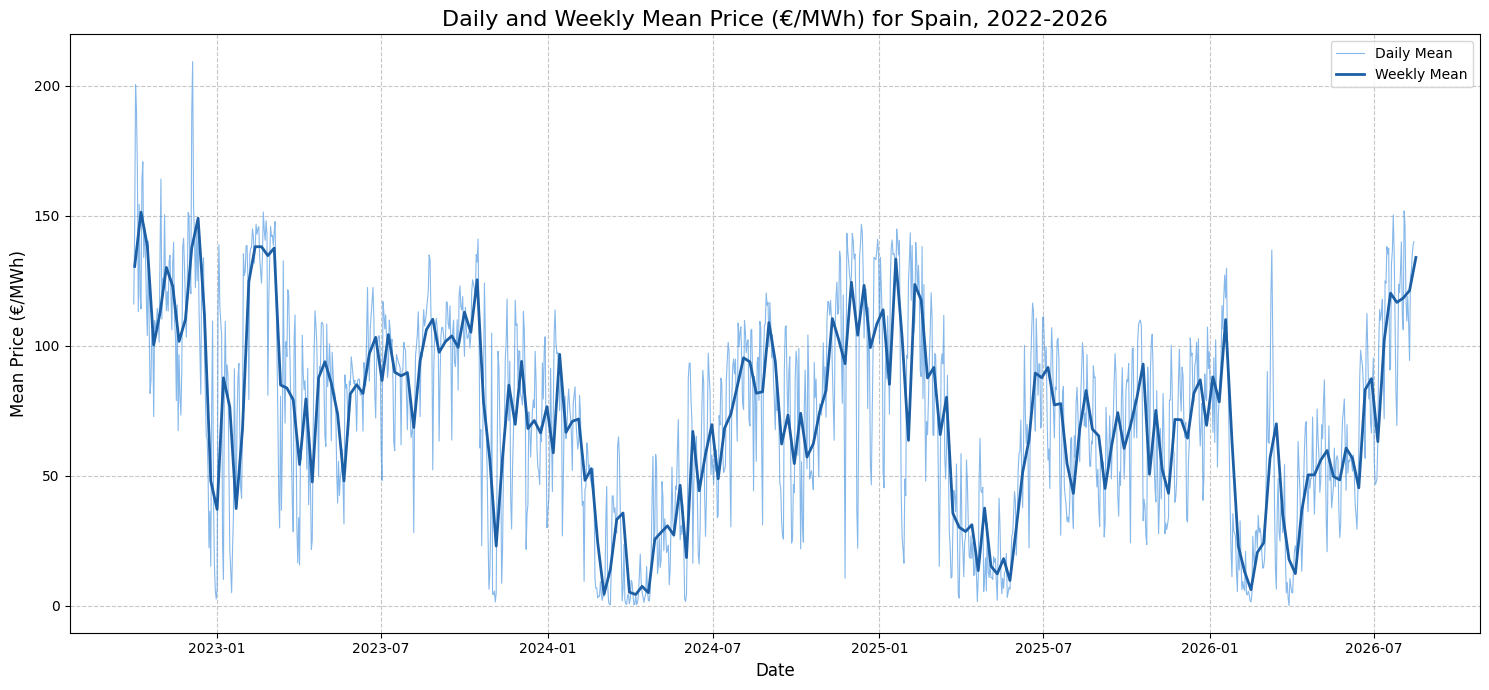

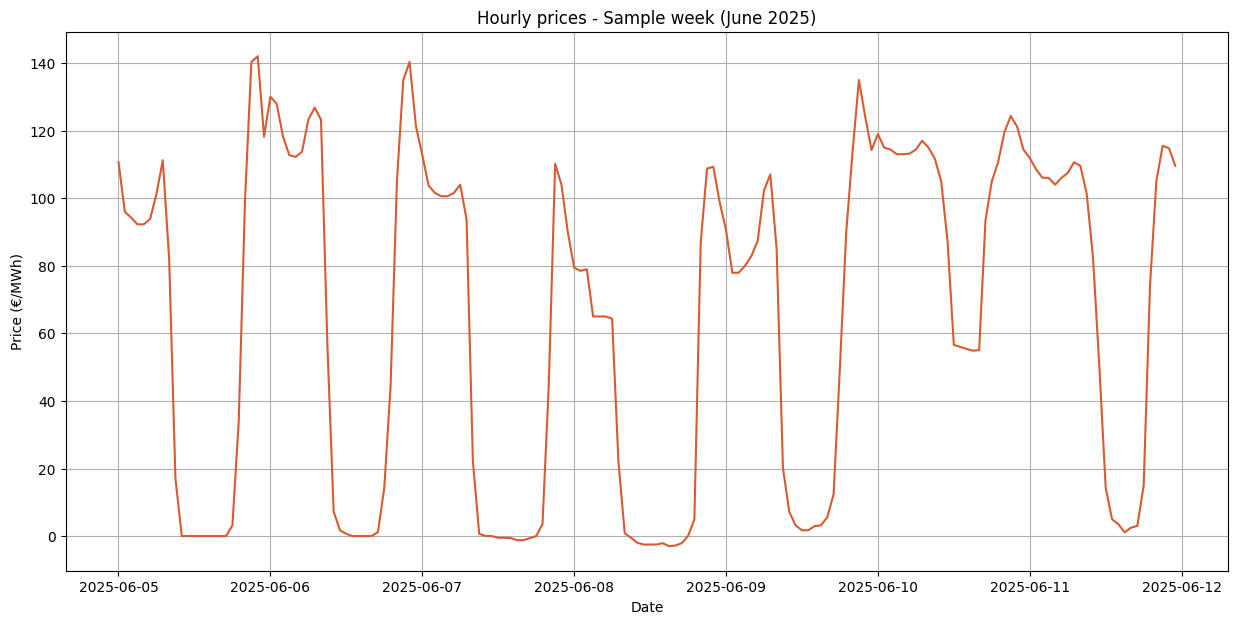

In [7]:
daily = df["price_eur_mwh"].resample("D").mean()
weekly = df["price_eur_mwh"].resample("W").mean()

plt.figure(figsize=(15, 7))

# Fully daily series

# Plot daily data with a lighter style
plt.plot(daily.index, daily.values, label='Daily Mean', color='#378ADD', alpha=0.6, linewidth=0.8)

# Plot weekly data with a stronger style
plt.plot(weekly.index, weekly.values, label='Weekly Mean', color='#1D5FA5', linewidth=2.0)

plt.title("Daily and Weekly Mean Price (€/MWh) for Spain, 2022-2026", fontsize = 16)
plt.xlabel("Date", fontsize = 12)
plt.ylabel("Mean Price (€/MWh)", fontsize = 12)
plt.grid(True, linestyle='--', alpha=0.7) # Added linestyle and alpha for clearer grid
plt.legend() # Add a legend to distinguish the lines
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

# One random week

sample_week = df["2025-06-05":"2025-06-11"]
plt.figure(figsize=(15, 7))
plt.plot(sample_week.index, sample_week.values, color='#D85A30')
plt.title("Hourly prices - Sample week (June 2025)")
plt.xlabel("Date")
plt.ylabel("Price (€/MWh)")
plt.grid(True)
plt.show()

**What can be observed from these plots**: The first chart displays the macro picture, with long-term trends, seasonal cycles and spike events. The bottom chart shows the weekly pattern, from which two clear daily humps can be observed (morning and evening peaks) and a trough overnight.

## **03 - Distibution of the data**

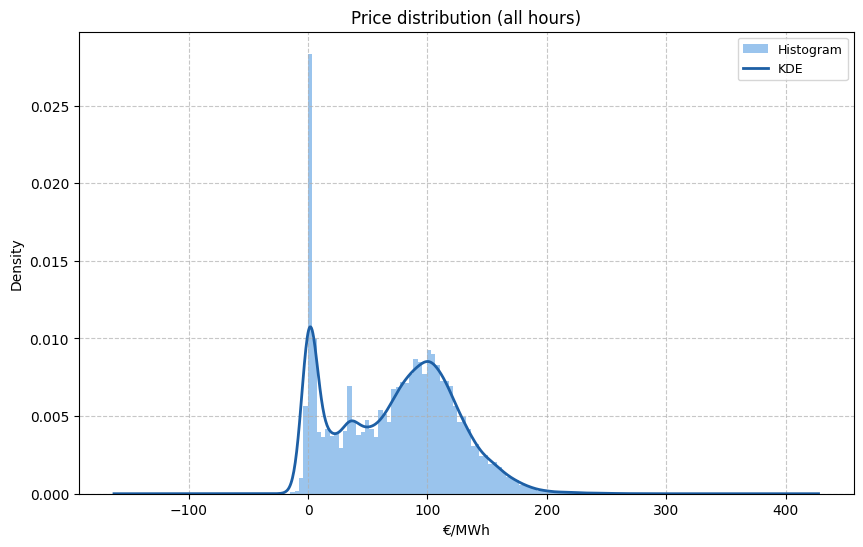

In [8]:
prices = df["price_eur_mwh"]

plt.figure(figsize=(10, 6)) # Creates a new figure for this plot

# Histogram with KDE
plt.hist(prices, bins=80, density=True, color="#378ADD", alpha=0.5, label="Histogram")
prices.plot.kde(ax=plt.gca(), color="#1D5FA5", lw=2, label="KDE") # plt.gca() gets the current axes
plt.title("Price distribution (all hours)")
plt.xlabel("€/MWh")
plt.ylabel("Density")
plt.legend(fontsize=9)
plt.grid(True, linestyle='--', alpha=0.7) # Add grid for clarity
plt.show()

**What we can observe from this graph**:

Price distribution (all hours, 2022–2026). The distribution is clearly bimodal and right-skewed, consistent with the structure of the electricity market. The first mode is concentrated near 0 €/MWh and corresponds to hours of low demand and high renewable penetration (early mornings, sunny mid-days); the second, wider one, is around 90–110 €/MWh and covers hours of higher demand (mornings and afternoons). The intermediate valley represents less frequent transition hours. The thin but long right tail corresponds to specific scarcity episodes where the price skyrockets.

This shape influences modeling decisions: (1) the presence of null and negative values makes MAPE unsuitable as a metric and motivates the use of MASE; (2) the multimodal nature, largely governed by the time of day, anticipates that calendar variables (hour, month) will be powerful predictors; (3) the tail of extreme prices warns that peaks, being rare, will be the most difficult part to predict and tend to be underestimated.

Value distribution near zero is a real signal, not a forward-fill artifact. The most repeated price is 0.00 €/MWh (1030 hours), followed by -0.01 (273) and a spread of other values (35.00, 3.52, 3.20, 100.00, 90.00…). The concentration at zero reflects the genuine market outcome of renewable surplus with low demand — when supply exceeds demand, the marginal price collapses to zero or slightly negative. No single filled value dominates abnormally, so the peak in the histogram is a real feature of the Spanish market, not an artifact of the A03 forward-fill.

## **04 - More interesting visualizations**

1) Annual seasonality (Average price per month)
2) Price heatmap: hour x day of week

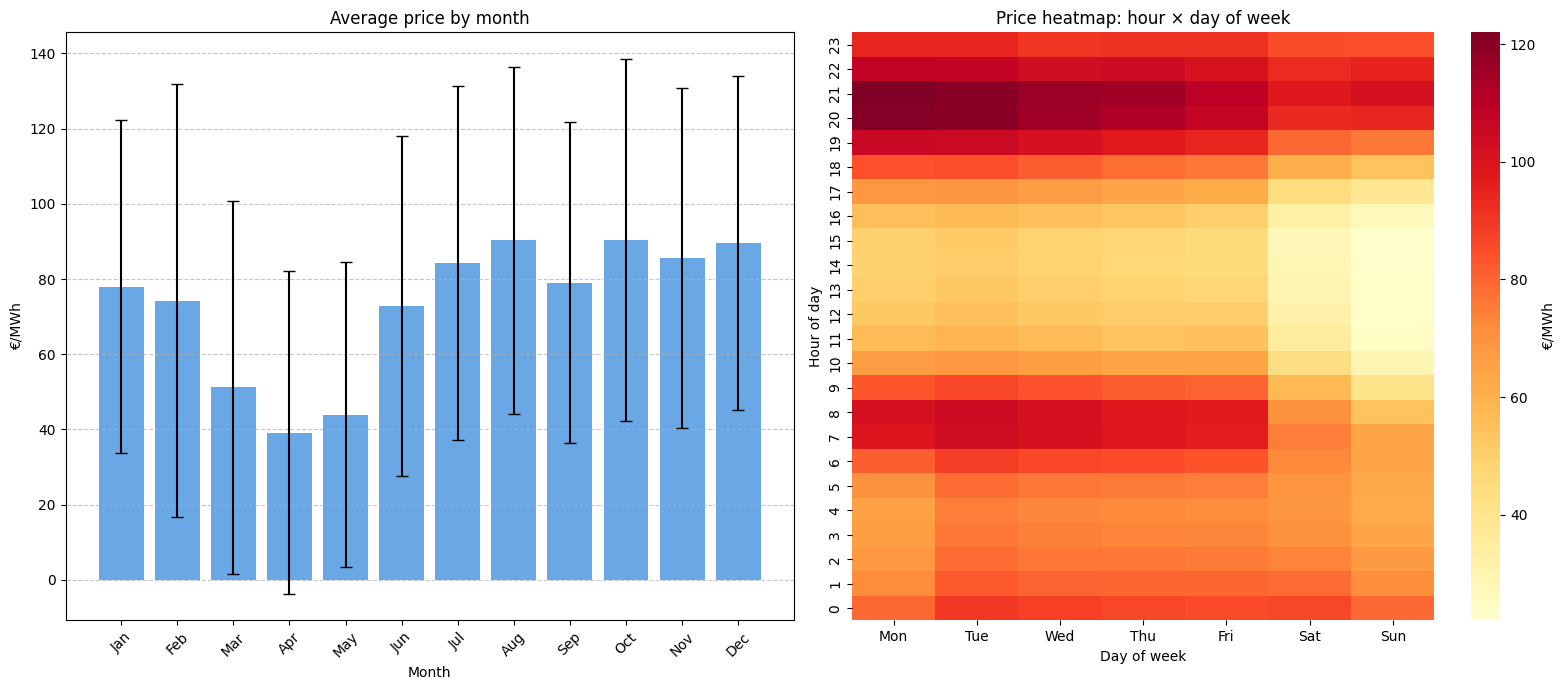

In [9]:
# --- Annual seasonality: average price by calendar month ---
month_mean = df.groupby(df.index.month)["price_eur_mwh"].mean()
month_std  = df.groupby(df.index.month)["price_eur_mwh"].std()

month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

# --- Heatmap: hour of day vs day of week ---
pivot = df.pivot_table(values="price_eur_mwh",
                       index=df.index.hour,
                       columns=df.index.dayofweek,
                       aggfunc="mean")

dow_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
pivot.columns = dow_labels

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 7)) # 1 row, 2 columns, adjust figsize as needed

# Subplot 1: Average price by month
axes[0].bar(range(1, 13), month_mean, yerr=month_std, capsize=4,
        color="#378ADD", alpha=0.75)
axes[0].set_title("Average price by month")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("€/MWh")
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(month_labels, rotation=45)
axes[0].grid(True, axis="y", linestyle="--", alpha=0.7)

# Subplot 2: Price heatmap
sns.heatmap(pivot, cmap="YlOrRd", annot=False,
            cbar_kws={"label": "€/MWh"}, ax=axes[1])
axes[1].set_title("Price heatmap: hour × day of week")
axes[1].set_xlabel("Day of week")
axes[1].set_ylabel("Hour of day")
axes[1].invert_yaxis() # To invert y-axis

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

**Average price by month**: This shows how energy prices vary throughout the year, revealing a clear seasonality. Peaks are observed in summer and winter, with a trough during spring.

**Heatmap analysis**: The heatmap reveals another clear pattern. The dark red cells (expensive) are weekday evenings (18–20h). The pale cells (cheap) are weekend nights and early mornings. It can also be observed the difference in price of the weekdays and weekends.

## **05 - Seasonal decomposition**

We will now split the price series into three components to better understand the underlying patterns and improve forecasting accuracy:

* **Trend**: The long-term direction
* **Seasonal**: The repeating pattern (daily and annual cycles)
* **Residual**: What's left after removing trend and seasonal (The noise the model will struggle with)

We will use an additive decomposition as seasonal variation is constant over time and does'nt grow with the price level:

`Series = Trend + Seasonality + Residuals`

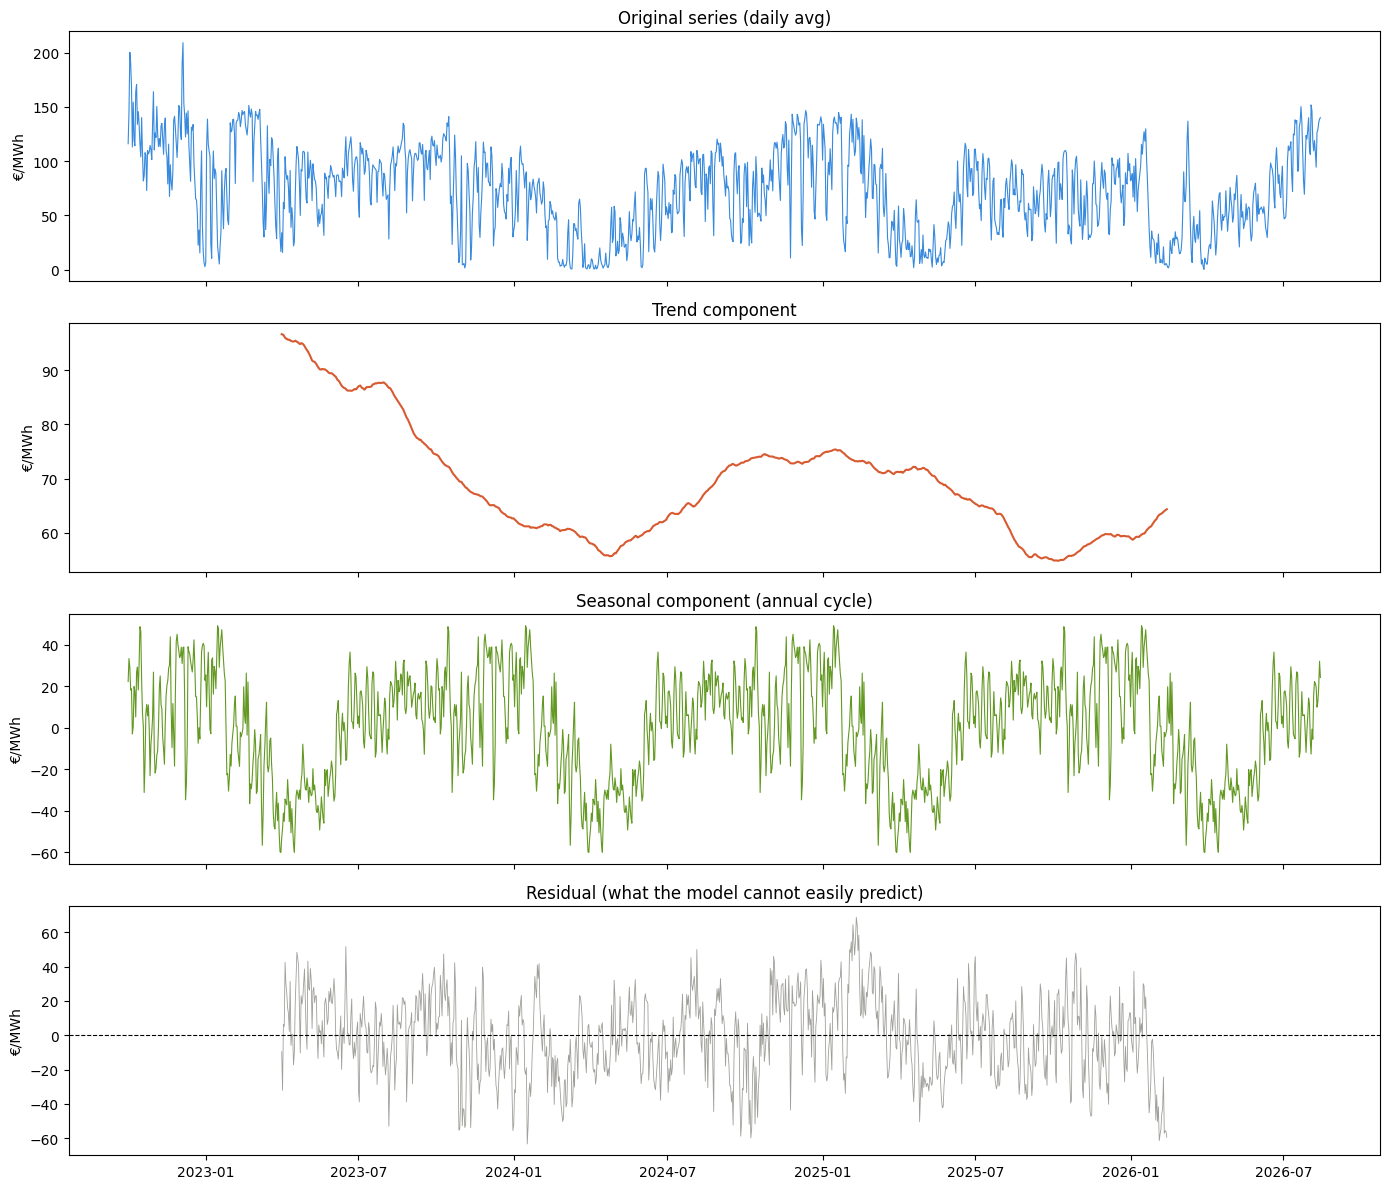

In [10]:
daily_avg = df["price_eur_mwh"].resample("D").mean().dropna()

decomp = seasonal_decompose(daily_avg, model="additive", period=365)
# decomp.plot() commented cells, plot the same but less visually friendly
# plt.show()

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

axes[0].plot(daily_avg.index, daily_avg.values, lw=0.8, color="#378ADD")
axes[0].set_title("Original series (daily avg)")
axes[0].set_ylabel("€/MWh")

axes[1].plot(decomp.trend.index, decomp.trend.values, lw=1.5, color="#D85A30")
axes[1].set_title("Trend component")
axes[1].set_ylabel("€/MWh")

axes[2].plot(decomp.seasonal.index, decomp.seasonal.values, lw=0.8, color="#639922")
axes[2].set_title("Seasonal component (annual cycle)")
axes[2].set_ylabel("€/MWh")

axes[3].plot(decomp.resid.index, decomp.resid.values, lw=0.6, color="#888780", alpha=0.8)
axes[3].axhline(0, color="black", lw=0.8, ls="--")
axes[3].set_title("Residual (what the model cannot easily predict)")
axes[3].set_ylabel("€/MWh")

plt.tight_layout()
plt.show()


### **What the decomposition shows**

The most useful panel is the **trend**: prices peaked after the 2022 gas crisis, fell into mid-2024, rebounded through 2025, and eased again in 2026. This confirms the data contains several distinct price regimes, a key reason the model needs multiple years of history.

The **residual** is clearly not random noise: its size changes over time (calm in 2023–2024, violent in late 2022 and early 2026) and it has a tail of upward spikes. This leftover structure is exactly what a lag- and calendar-based model can learn.


## **06 - Circular encoding**

As an integer, 23 and 0 are 23 hours away, but in reality we know that this is not true. They are 1 hour away, and we need to make sure our model understands this via circular encoding. Which puts hour 23 and hour 0 close together in 2D space. Same logic applies to month and day_of_week.

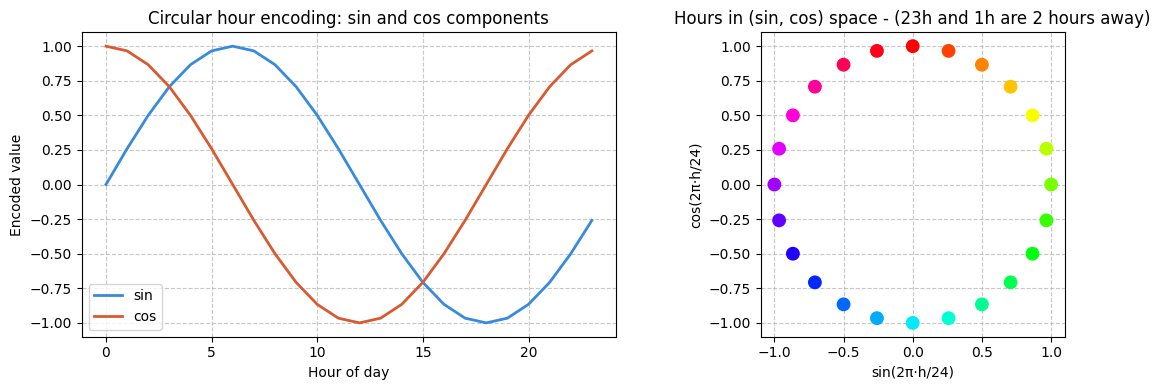

In [24]:
hours = np.arange(24)
hour_sin = np.sin(2 * np.pi * hours / 24)
hour_cos = np.cos(2 * np.pi * hours / 24)

fig, axes = plt.subplots(1, 2, figsize=(12,4))

axes[0].plot(hours, hour_sin, lw = 2, color="#378ADD")
axes[0].plot(hours, hour_cos, lw = 2, color="#D85A30")
axes[0].set_title("Circular hour encoding: sin and cos components")
axes[0].set_xlabel("Hour of day")
axes[0].set_ylabel("Encoded value")
axes[0].legend(["sin", "cos"])
axes[0].grid(True, linestyle='--', alpha=0.7)

axes[1].scatter(hour_sin, hour_cos, c = hours, cmap = "hsv", s = 80, zorder=3)
axes[1].set_title("Hours in (sin, cos) space - (23h and 0h are 1 hour away)")
axes[1].set_xlabel("sin(2π·h/24)")
axes[1].set_ylabel("cos(2π·h/24)")
axes[1].grid(True, linestyle='--', alpha=0.7)
axes[1].set_aspect("equal")


plt.tight_layout()


## **07 - Feature Candidates**

On following notebooks we will create some baseline models and an xgboost model with features that reflect patterns we have seen in this notebook:

**Calendar features:**

* `hour_of_day` [0-23] strong intraday signal
* `hour_sin / hour_cos` circular encoding
* `is_weekend` [0/1]
* `day_of_week` [0-6]
* `month` [1-12] annual seasonality
* `month_sin / month_cos` month circular encoding

**Lag features:**

* `price_lag_24h`same hour yesterday
* `price_lag_168h` same hour last week
